# HOMEWORK 1: DEEP LEARNING

In [25]:
import torch
import itertools
import torchvision.transforms as transforms
import sklearn
from torch import nn
from torch.nn import functional as F

from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import DataLoader 
from torchvision.transforms import ToTensor
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

import numpy as np 
import pandas as pd
from numpy.linalg import pinv
from numpy.linalg import norm

import tqdm
from tqdm.notebook import trange

import matplotlib.pyplot as plt 
%matplotlib inline  

In [58]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Problem 1

In short, a machine learning (ML) algorithm is a model with a set of parameters that can learn from data. The algorithm is an ML algorithm if it learns from experience E (e.g. a dataset of images of cats and dogs) with respect to some class of tasks T (e.g. deciding of the image is a cat or a dog) and a performace measure P (e.g. how many images are classified correctly) and its performance at task T, as measured by P, improves with experience E. In this way machine learning-enabled programs are able to learn, grow, and change by themselves when exposed to new data. They are  us to solve problems that are too difficult for fixed programs. The "learning" part is the process of attaining the ability to perform the task. The learning is basically what happens after the model has produced an estimate given a new observation and a signal directing it towards minimizing a cost (= maximizing an objective). 

Three main types of learning exist, being supervised learning, unsupervised learning and reinforcement learning. In the supervised scenario, the model learns by minimizing the error between the model's estimate and the ground truth (the correct answer). In unsupervised learning, the model uses a constraint to learn, for example a measure of sparsity, maintaining low entropy within the parameters, or maximizing the separation between cluster centroids. For the last scenario, being reinforcement learning, the training consists of receiving a signal and deciding how positive or negative the reward is.

# Problem 2

In [19]:
def roundsd(ar, sd):
    new_array = np.zeros(len(ar))
    for i in range(len(ar)):
        new_array[i] = round(ar[i], sd - int(np.floor(np.log10(np.abs(ar[i])))) - 1)
    return new_array

In [20]:
def problem2_evaluate_function_on_random_noise(N, sigma):
    """Sample N points uniformly from the interval [-1,3],
    add random noise, and output the function y = x^2 - 3x + 1

    Parameters
    ----------
    N : int
        The number of points
    sigma : float
        The standard deviation of noise to add to the randomly generated points.

    Returns
    -------
    x, y (list, list) 
        x, the randomly generated points with added noise
        y, the function evaluated at these points.
    """
    x = np.random.uniform(low=-1.0, high=3.0, size=N)
    y = x**2 - 3*x + 1
    y = y + np.random.normal(0, sigma, size=N)
    
    return x, y

def problem2_fit_polynomial(x, y, degree, regularization = None):
    """Returns optimal coefficients for a polynomial of the given degree
    to fit the data, using the Moore-Penrose Pseudoinverse (specified in the assignment)
    Note: this function only needs to function for degrees 1,2, and 9 --
    but you are welcome build something that works for any degree.
    By incorporating the value of the regularization parameter, this function should work 
    for both 2.2 and 2.3

    Parameters
    ----------
    x : list of floats 
        The input x values
    y : list of floats
        The input y values
    degree : int
        The degree of the polynomial to fit
    regularization : float
        The parameter lambda which specifies the degree of regularization to apply. Default 0.

    Returns
    -------
    list of floats  
        The coefficients of the polynomial.
    """
    if regularization == None:
        lambd = 0
    else:
        lambd = regularization
        
    X = np.ones((len(x), 1))

    for i in np.arange(1,degree+1):
        newcolx = np.array([x**i]).T
        X = np.append(X, newcolx, axis = 1)

    coeffs = pinv(X.T @ X + lambd*np.identity(degree + 1)) @ X.T @ y


    return coeffs

### Problem 2.1

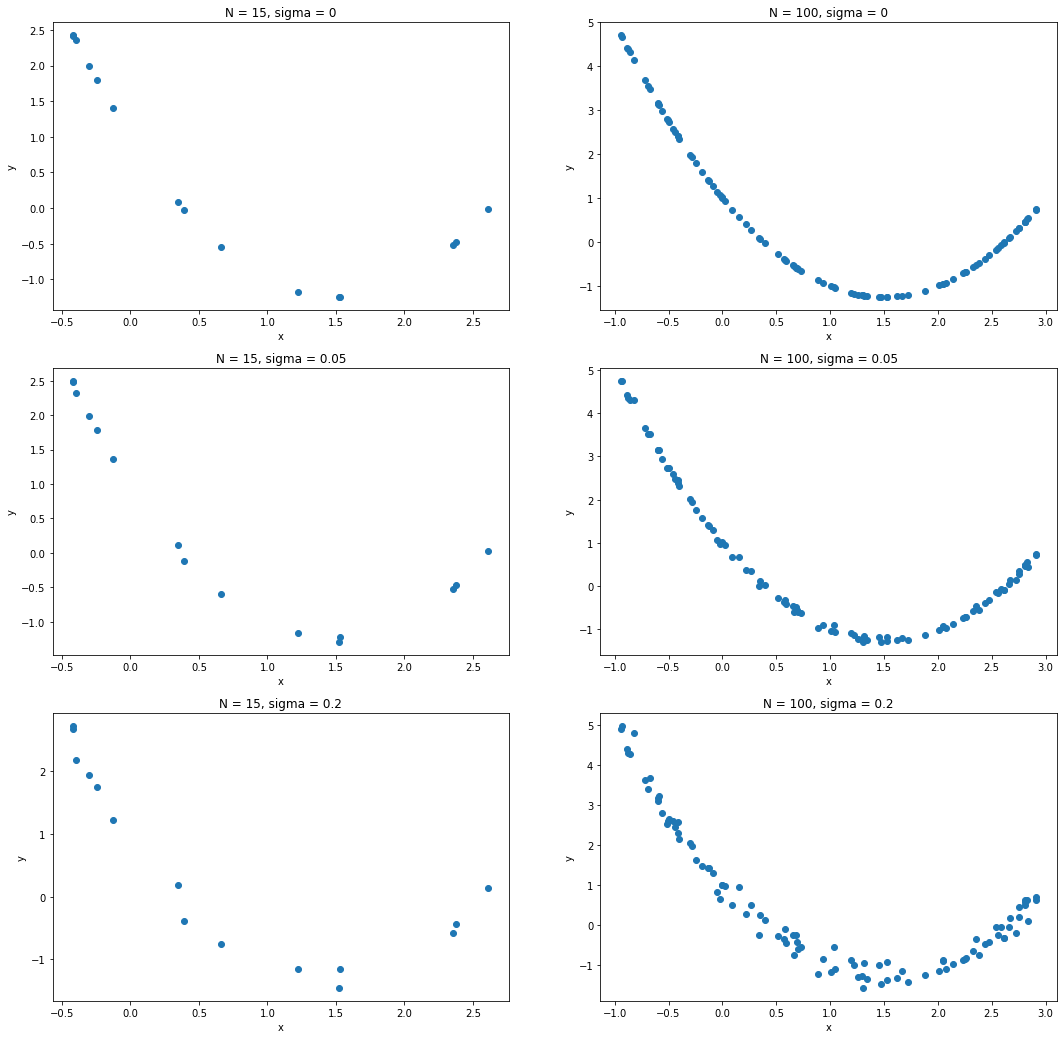

In [21]:
N = [15, 100]
sigma = [0, 0.05, 0.2]

xset = []
yset = []

num = 0

f, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (18, 18))
axes = axes.ravel()

for s in sigma:
    for n in N:
        #np.random.seed(355)
        np.random.seed(21212)
        x, y = problem2_evaluate_function_on_random_noise(n, s)
        xset.append(x)
        yset.append(y)
        scttt = axes[num].scatter(x, y)
        
        axes[num].set_title(f'N = {n}, sigma = {s}')
        axes[num].set_xlabel(f'x')
        axes[num].set_ylabel(f'y')
        num += 1

plt.show()

In [22]:
SN = []
for i in sigma:
    for j in N:
        SN.append([i,j])

### Problem 2.2

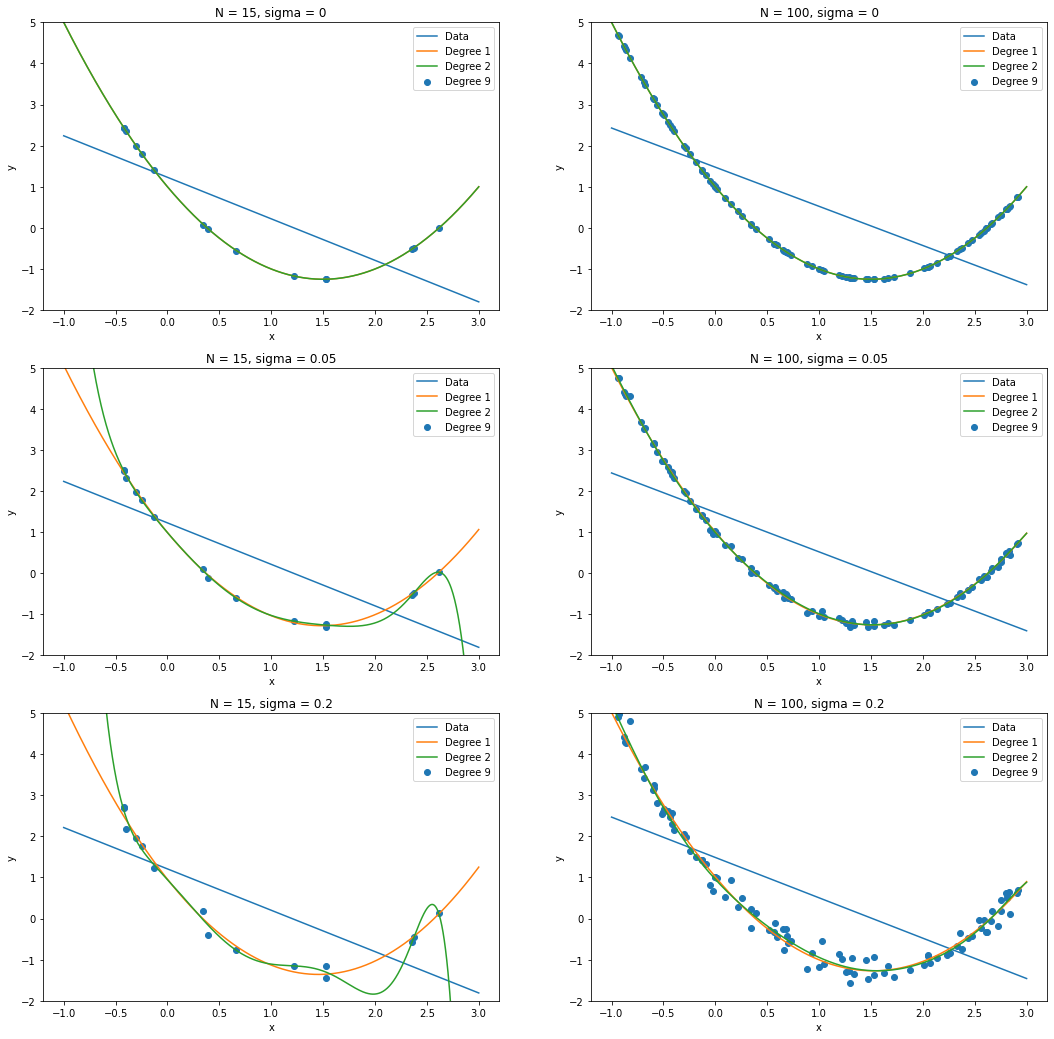

In [23]:
polyn = [1, 2, 9]
MSEvec = []
beta_full = []
num = 0

f, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (18, 18))
axes = axes.ravel()

for graph in range(len(N)*len(sigma)):
    scttt = axes[num].scatter(xset[graph], yset[graph])
        
    axes[num].set_title(f'N = {SN[graph][1]}, sigma = {SN[graph][0]}')
    axes[num].set_xlabel(f'x')
    axes[num].set_ylabel(f'y')
    
    for p in polyn:
        t = np.linspace(-1,3,1000)
        T = np.ones((len(t), 1))
        X = np.ones((len(xset[graph]), 1))

        for i in np.arange(1,p+1):
            newcolt = np.array([t**i]).T
            T = np.append(T, newcolt, axis = 1)
            newcolx = np.array([xset[graph]**i]).T
            X = np.append(X, newcolx, axis = 1)
            
        beta_vector1 = problem2_fit_polynomial(xset[graph], yset[graph], p, regularization = None)
        beta_full.append(roundsd(beta_vector1,3))
        yhat = beta_vector1 @ X.T
        MSE = np.mean(np.square(yset[graph] - yhat))
        MSEvec.append(MSE)
        axes[num].plot(t, beta_vector1 @ T.T)
        axes[num].set_ylim(-2,5)
        axes[num].legend(['Data', 'Degree 1', 'Degree 2', 'Degree 9'])
    num += 1
    
plt.show()

The linear function (1st degree polynomial) clearly underfits the data, because the model is not complex enough, leading to a high bias. The 2nd degree polynomial does a great job at fitting the data. The 9th degree polynomial, however, leads to an overfit of the training data as the model is too complex, leading to high test errors (the overfit is more clear when less training data is available). This behavior is also visible in the MSE-values.

In [28]:
N_full = [15,15,15, 100, 100, 100] * 3
Sigma_full = [0] * 6 + [0.05] * 6 + [0.2] * 6
Degree_full = [1,2,9] * 6
MSE_full = roundsd(MSEvec, 3)

In [29]:
pd.set_option('display.max_colwidth', None)
d = {'N': N_full, 'Sigma': Sigma_full, 'Degree': Degree_full, 'MSE': MSE_full, 'beta-coefficients': beta_full}
df = pd.DataFrame(data=d)
df

,N,Sigma,Degree,MSE,beta-coefficients
0,15,0.00,1,7.070000e-01,"[1.23, -1.01]"
1,15,0.00,2,4.130000e-30,"[1.0, -3.0, 1.0]"
2,15,0.00,9,5.560000e-14,"[1.0, -3.0, 1.0, 4.01e-07, -1.05e-07, -1.37e-06, 2.24e-06, -1.48e-06, 4.51e-07, -5.23e-08]"
3,100,0.00,1,1.430000e+00,"[1.48, -0.952]"
4,100,0.00,2,1.440000e-29,"[1.0, -3.0, 1.0]"
5,100,0.00,9,2.660000e-17,"[1.0, -3.0, 1.0, 3.72e-08, -9.91e-08, 1.67e-08, 6.65e-08, -5.18e-08, 1.49e-08, -1.53e-09]"
6,15,0.05,1,7.420000e-01,"[1.22, -1.01]"
7,15,0.05,2,1.620000e-03,"[0.989, -3.05, 1.02]"
8,15,0.05,9,1.100000e-03,"[0.987, -2.94, 0.669, -0.406, 2.06, -2.68, 2.12, -1.15, 0.355, -0.0447]"
9,100,0.05,1,1.420000e+00,"[1.48, -0.96]"


### Problem 2.3

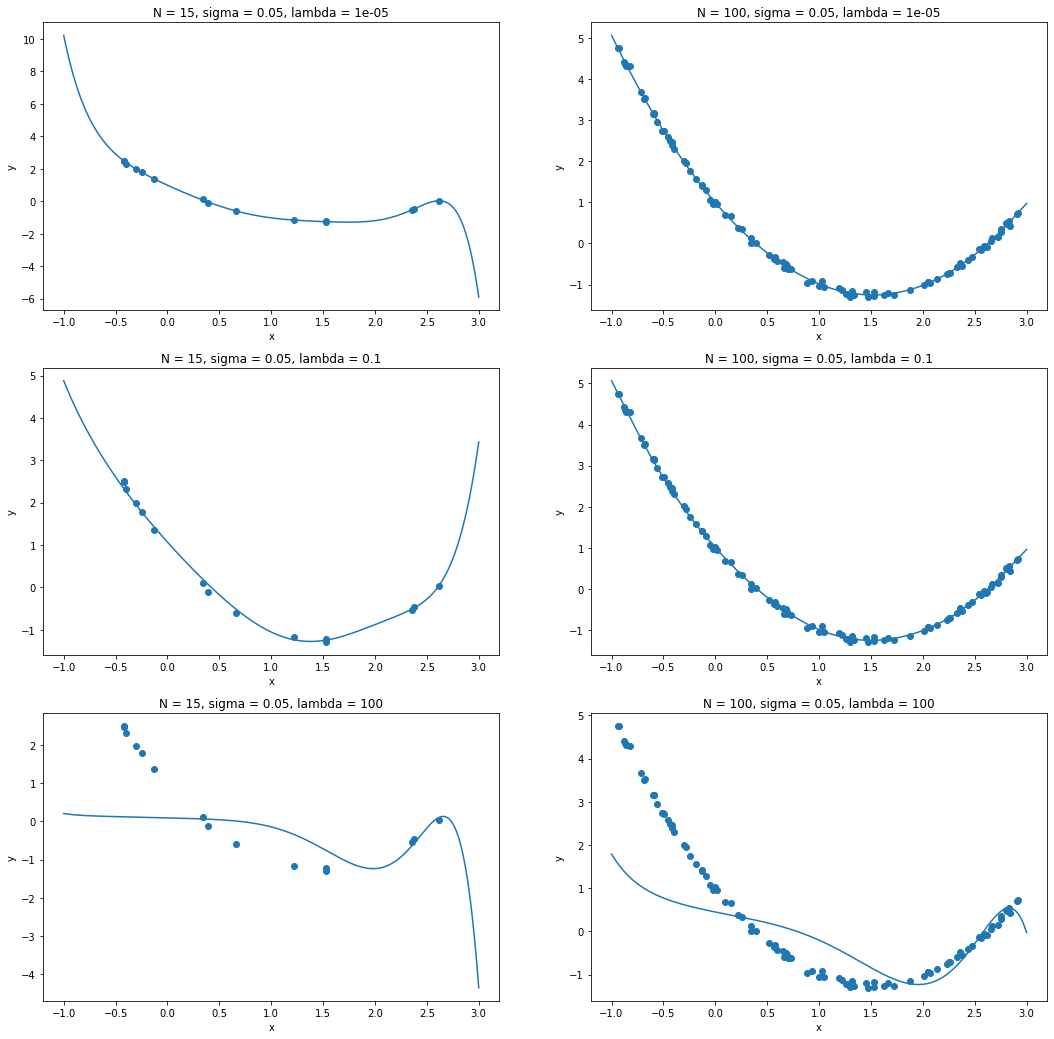

In [30]:
lambdas = [0.00001, 0.10, 100]
graphs = [2, 3]
MSEvec = []
beta_full = []
num = 0

f, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (18, 18))
axes = axes.ravel()

for l in lambdas:
    for graph in graphs:
        
        scttt = axes[num].scatter(xset[graph], yset[graph])

        axes[num].set_title(f'N = {SN[graph][1]}, sigma = {SN[graph][0]}, lambda = {l}')
        axes[num].set_xlabel(f'x')
        axes[num].set_ylabel(f'y')
    
        X = np.ones((len(xset[graph]), 1))
        t = np.linspace(-1,3,1000)
        T = np.ones((len(t), 1))

        for i in np.arange(1,p+1):
            newcolx = np.array([xset[graph]**i]).T
            newcolt = np.array([t**i]).T
            X = np.append(X, newcolx, axis = 1)
            T = np.append(T, newcolt, axis = 1)

        beta_vector1 = problem2_fit_polynomial(xset[graph], yset[graph], 9, l)
        beta_full.append(roundsd(beta_vector1,3))
        yhat = beta_vector1 @ X.T
        MSE = np.mean(np.square(yset[graph] - yhat))
        MSEvec.append(MSE)
        axes[num].plot(t, beta_vector1 @ T.T)
        num += 1
    
plt.show()

If the penalization parameter $\lambda$ is low (close to zero), there will be very little penalization on the coefficients, leading to a solution that looks like the least square solution. That is why a $\lambda$ equal to 1e-5 leads to an overfit of the data. Choosing $\lambda$ equal to 0.1 leads to an appropriate fit, where the behavior of the true function (having a 2nd degree polynomial) is captured much better. A large $\lambda$ leads to too much penalization, resulting in an underfit.

In [31]:
N_full = [15, 100] * 3
Sigma_full = [0.05] * 6 
Degree_full = [9] * 6
Lambda_full = [1e-5] * 2 + [0.1] * 2 + [100] * 2
MSE_full = roundsd(MSEvec, 3)

In [33]:
pd.set_option('display.max_colwidth', None)
d = {'N': N_full, 'Sigma': Sigma_full, 'Degree': Degree_full, 'MSE': MSE_full, 'Lambda': Lambda_full,
     'beta-coefficients': beta_full}
df = pd.DataFrame(data=d)
df

,N,Sigma,Degree,MSE,Lambda,beta-coefficients
0,15,0.05,9,0.00110,0.00001,"[0.983, -2.93, 0.769, -0.649, 1.86, -1.59, 0.82, -0.426, 0.162, -0.0243]"
1,100,0.05,9,0.00219,0.00001,"[0.989, -2.94, 1.05, -0.146, 0.0153, 0.0723, -0.0279, -0.00877, 0.00644, -0.00093]"
2,15,0.05,9,0.00832,0.10000,"[1.07, -2.73, 0.515, -0.211, 0.288, 0.0571, 0.0154, -0.0784, 0.0265, -0.00198]"
3,100,0.05,9,0.00242,0.10000,"[1.01, -2.84, 0.902, -0.3, 0.29, 0.0508, -0.151, 0.0636, -0.00961, 0.000339]"
4,15,0.05,9,1.71000,100.00000,"[0.093, -0.0671, -0.0179, -0.0449, -0.0434, -0.0482, -0.0365, -0.00586, 0.0377, -0.00992]"
5,100,0.05,9,1.45000,100.00000,"[0.449, -0.489, 0.122, -0.298, 0.0707, -0.155, 0.133, -0.0519, 0.0196, -0.00369]"


# Problem 3

### Problem 3.1

In [10]:
url = "/Users/louisdeschuttere/Documents/Yale University/Semester 2/Deep Learning/Homeworks/HW1/problem3_data_seed.dat"
data = np.genfromtxt(url)
print(data)

n = data.shape[0]
m = data.shape[1]

[[15.26   14.84    0.871  ...  2.221   5.22    1.    ]
 [14.88   14.57    0.8811 ...  1.018   4.956   1.    ]
 [14.29   14.09    0.905  ...  2.699   4.825   1.    ]
 ...
 [13.2    13.66    0.8883 ...  8.315   5.056   3.    ]
 [11.84   13.21    0.8521 ...  3.598   5.044   3.    ]
 [12.3    13.34    0.8684 ...  5.637   5.063   3.    ]]


In [11]:
for i in range(m-1):
    col = data[:,i]
    colmin = np.min(col)
    colmax = np.max(col)
    for j in range(n):
        data[j,i] = (data[j,i] - colmin) / (colmax - colmin)
print(data)

[[0.44098206 0.50206612 0.5707804  ... 0.18930164 0.34515017 1.        ]
 [0.40509915 0.44628099 0.66243194 ... 0.03288302 0.21516494 1.        ]
 [0.34938621 0.34710744 0.87931034 ... 0.25145302 0.1506647  1.        ]
 ...
 [0.24645892 0.25826446 0.7277677  ... 0.98166664 0.26440177 3.        ]
 [0.11803588 0.16528926 0.39927405 ... 0.36834441 0.25849335 3.        ]
 [0.16147309 0.19214876 0.54718693 ... 0.63346292 0.26784835 3.        ]]


In [12]:
X = data[:,0:7]
y = data[:,7]

### Problem 3.2

In [13]:
def arraysplitter(array, groups):
    n = len(array)
    split_array = []
    
    g = n // groups
    rest = n % groups
    for i in range(groups):
        arr = array[(i*g):((i+1)*g)]
        split_array.append(arr)
    if (rest != 0):
        split_array[i] = split_array[i] + array[(n-rest):]
    return split_array

In [16]:
def problem3_knn_classifier(train_data, train_labels, test_data, k):
    """A kth Nearest Neighbor classified. Accepts points and training labels, 
    and returns predicted labels for each point in the dataset.

    Parameters
    ----------
    train_data : ndarray
        The training points, in an n x d array, where n is the number of points and d is the dimension.
    train_labels : list of classes
        The training labels. They should correspond directly to the points in the training data array.
    test_data : ndarray
        The unlabelled data, to be labelled by the classifier
    k : positive int
        The number of nearest neighbors to consult.

    Returns
    -------
    predicted_labels : list
        The labels outputted by the classifier for each of the test datapoints.
    """
    predicted_labels = []
    
    if len(test_data.shape) == 1:
        test_data = [test_data]
    
    for testd in test_data:
        distances = norm(train_data - testd, axis=1)
        nearest_neighbor_data = distances.argsort()[:k]
        nearest_neighbor_labels = (train_labels[nearest_neighbor_data]).astype(int)
        test_label = np.bincount(nearest_neighbor_labels).argmax()
        predicted_labels.append(test_label)
        
    return predicted_labels

Leave on out cross validation

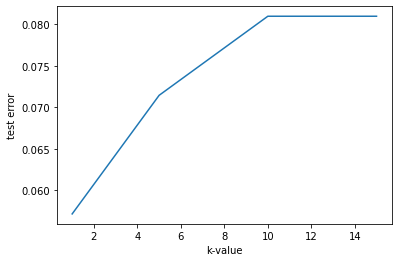

In [17]:
K = [1, 5, 10, 15]
test_error_k = []

for k in K:
    ftlabels = []
    for test in range(len(y)):
        train = np.delete(np.arange(0,len(y)), test)
        X_train = X[train, :]
        X_test = X[test,:]
        y_train = y[train]
        y_test = y[test]
        concl = (y_test == problem3_knn_classifier(X_train, y_train, X_test, k))
        ftlabels.append(concl)
    test_acc = np.mean(ftlabels)
    test_error_k.append(1 - test_acc)

plt.plot(K, test_error_k)
plt.xlabel("k-value")
plt.ylabel("test error")
plt.show()

5-fold Cross validation

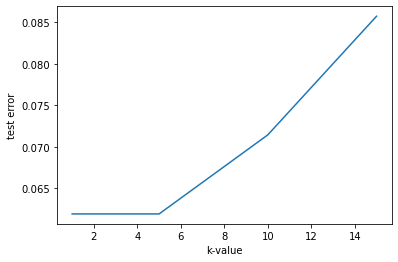

In [43]:
K = [1, 5, 10, 15]
test_error_k = []

xfold = 5

for k in K:
    np.random.seed(136677512)
    ftlabels = []
    indices = np.arange(0,len(y))
    np.random.shuffle(indices)
    fivefold = arraysplitter(indices.tolist(), xfold)
    for test in fivefold:
        train = np.delete(np.arange(0,len(y)), test)
        X_train = X[train, :]
        X_test = X[test,:]
        y_train = y[train]
        y_test = y[test]
        concl = (y_test == problem3_knn_classifier(X_train, y_train, X_test, k)).tolist()
        ftlabels = ftlabels + concl
    
    test_acc = np.mean(ftlabels)
    test_error_k.append(1 - test_acc)

plt.plot(K, test_error_k)
plt.xlabel("k-value")
plt.ylabel("test error")
plt.show()

The k-NN algorithm has the tendency to overfit the training data for smaller values of k (close to 1), leading to a large test error. However, in this case, the k-NN algorithm does not seem to overfit and results in a small test error even for smaller values of k. Large values of k (close to n, the latter being the amount of datapoints), lead to underfitting. In this case, however, the largest value of k (equal to 15) is still small enough and does not lead to underfitting. This behavior is visible on both the LOOCV result and the 5-fold cross validation result. 

### Problem 3.3

Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
xfold = 5

np.random.seed(22)
indices = np.arange(0,len(y))
np.random.shuffle(indices)
fivefold = arraysplitter(indices.tolist(), xfold)
ftlabels_test = []
ftlabels_train = []
    
for test in fivefold:
    train = np.delete(np.arange(0,len(y)), test)
    X_train = X[train, :]
    X_test = X[test,:]
    y_train = y[train]
    y_test = y[test]
    clf_log = LogisticRegression(random_state=0).fit(X_train, y_train)
    concl_train = (y_train == clf_log.predict(X_train)).tolist()
    ftlabels_train = ftlabels_train + concl_train
    concl_test = (y_test == clf_log.predict(X_test)).tolist()
    ftlabels_test = ftlabels_test + concl_test

train_acc = np.mean(ftlabels_train)
test_acc = np.mean(ftlabels_test)

print("The train error for logistic regression is: ", 1 - train_acc)
print("The test error for logistic regression is: ", 1 - test_acc)

The train error for logistic regression is:  0.06666666666666665
The test error for logistic regression is:  0.0714285714285714


Decision Trees

In [46]:
from sklearn import tree

In [47]:
xfold = 5

np.random.seed(22)
indices = np.arange(0,len(y))
np.random.shuffle(indices)
fivefold = arraysplitter(indices.tolist(), xfold)
ftlabels_test = []
ftlabels_train = []
    
for test in fivefold:
    train = np.delete(np.arange(0,len(y)), test)
    X_train = X[train, :]
    X_test = X[test,:]
    y_train = y[train]
    y_test = y[test]
    clf_tree = tree.DecisionTreeClassifier()
    clf_tree = clf_tree.fit(X_train, y_train)
    concl_train = (y_train == clf_tree.predict(X_train)).tolist()
    ftlabels_train = ftlabels_train + concl_train
    concl_test = (y_test == clf_tree.predict(X_test)).tolist()
    ftlabels_test = ftlabels_test + concl_test

train_acc = np.mean(ftlabels_train)
test_acc = np.mean(ftlabels_test)

print("The train error for decision trees is: ", 1 - train_acc)
print("The test error for decision trees is: ", 1 - test_acc)

The train error for decision trees is:  0.0
The test error for decision trees is:  0.09047619047619049


Two other classifiers have been applied to the data set, being logistic regression and decision trees. For both methods, the training error and test are have been calculated through 5-fold cross validation. When the results are compared, it can be seen that logistic regression is leading to a slightly smaller test error than decision trees (20 % smaller). This could be due to decision trees having more tendency to overfit the training data (which is visible in the training error of 0) leading to a higher test error. For smaller k (up to k=10), the k-NN classifier performs slightly better (in terms of smaller test error) than the logistic regression classifier and the decision trees. For larger k, the logistic regression classifier surpasses the k-NN classifier in terms of performance. To conclude, the method of choice for a classifier for this data set would go to k-NN with a small k (for example 5). Note that the above calculations are subjected to randomness and that the values for the test errors should not be considered as fixed.

# Problem 4

### Problem 4.1

Suppose we take all the weights and biases in a network of perceptrons, and multiply them by a positive constant, c > 0, the behavior of the network will not change. This can be proven as follows:

Consider a network of perceptrons, each perceptron will have the following activation rule:

$$
\begin{eqnarray}
  \mbox{z} = \left\{
    \begin{array}{ll}
      0 & \mbox{if } w\cdot x + b \leq 0 \\
      1 & \mbox{if } w\cdot x + b > 0
    \end{array}
  \right.
\end{eqnarray}
$$

with z being the output, w representing the weights and b representing the bias. Now we multiply both weights and biases by the positive constant c:

$$
\begin{eqnarray}
  \mbox{z} = \left\{
    \begin{array}{ll}
      0 & \mbox{if } cw\cdot x + cb \leq 0 \\
      1 & \mbox{if } cw\cdot x + cb > 0
    \end{array}
  \right.
\end{eqnarray}
$$

Which can be rewritten as:

$$
\begin{eqnarray}
  \mbox{z} = \left\{
    \begin{array}{ll}
      0 & \mbox{if } c(w\cdot x + b) \leq 0 \\
      1 & \mbox{if } c(w\cdot x + b) > 0
    \end{array}
  \right.
\end{eqnarray}
$$

Because the value of c is strictly greater than zero, it can just be deleted. Summarized, multiplying the weights and biases by a positive constant will only change the magnitude of the left hand side of the equation, not its sign. This means it doesn't affect the output. This holds for every neuron, so the behavior of the network will not change.

### Problem 4.2

Suppose the weights and biases are such that
wx + b $\neq$ 0 for the input x to any particular perceptron in the network. If we would replace all the perceptrons in the network from problem 4.1 by sigmoid neurons, and multiply the weights and biases by a positive constant c > 0, then in the the limit as $c \rightarrow \infty$ the behavior of this network of sigmoid neurons will be exactly the same as
the network of perceptrons. This can be proven as follows:

The sigmoid neuron can be written as follows:

$$
\begin{eqnarray}
  \sigma(w\cdot x + b) \equiv \frac{1}{1+e^{-(w\cdot x + b)}}
\end{eqnarray}
$$

When the weights and biases are multiplied by a positive constant c > 0, the following is obtained:

$$
\begin{eqnarray}
  \sigma(c(w\cdot x + b)) \equiv \frac{1}{1+e^{-c(w\cdot x + b)}}
\end{eqnarray}
$$

When $c \rightarrow \infty$, the output of the sigmoid neuron will depend on the whether $w\cdot x + b < 0$ or $w\cdot x + b > 0$. In the first case, the exponential becomes $e^{\infty}$, which leads to a sigmoid output equal to 0. In the second case, exponential becomes $e^{-\infty}$, which leads to a sigmoid output equal to 1. This is equivalent to:

$$
\begin{eqnarray}
  \mbox{$\sigma$} = \left\{
    \begin{array}{ll}
      0 & \mbox{if } w\cdot x + b < 0 \\
      1 & \mbox{if } w\cdot x + b > 0
    \end{array}
  \right.
\end{eqnarray}
$$

If the weights and biases are such that wx + b $\neq$ 0, this will be exactly the same as the network of perceptrons. 

On the other hand, when wx + b = 0 is possible for one of the perceptrons, this property does not hold anymore, as the sigmoid neuron would output a 0.5.

### Problem 4.3

In [48]:
def network43(X):

    W1 = np.array([[0.6, -0.7], [0.5, 0.4], [-0.6, 0.8]])
    b1 = np.array([-0.4, -0.5])
    W2 = np.array([1,1])
    b2 = np.array([-0.5])

    hidden_layer = np.where((np.dot(X, W1) + b1) > 0, 1, 0)
    scores = np.where((np.dot(hidden_layer, W2) + b2) > 0, 1, 0)

    return scores

In [49]:
inputs4 = [
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [1,0,0],
    [0,1,1],
    [1,0,1],
    [1,1,0],
    [1,1,1]
]

for inp in inputs4:
    print(network43(inp))

[0]
[1]
[1]
[1]
[1]
[0]
[1]
[1]


### Problem 4.4

In [50]:
def network44(X):

    W1 = np.array([[0.6, -0.7], [0.5, 0.4], [-0.6, 0.8]])
    b1 = np.array([-0.4, -0.5])
    W2 = np.array([1,1])
    b2 = np.array([-0.5])

    hidden_layer = 1 / (1 + np.exp(-(np.dot(X, W1) + b1)))
    scores = 1 / (1 + np.exp(-(np.dot(hidden_layer, W2) + b2)))

    return scores

In [51]:
for inp in inputs4:
    print(network44(inp))

[0.569265]
[0.58501229]
[0.62245933]
[0.56986717]
[0.63314399]
[0.57508402]
[0.61732588]
[0.62831133]


### Problem 4.5

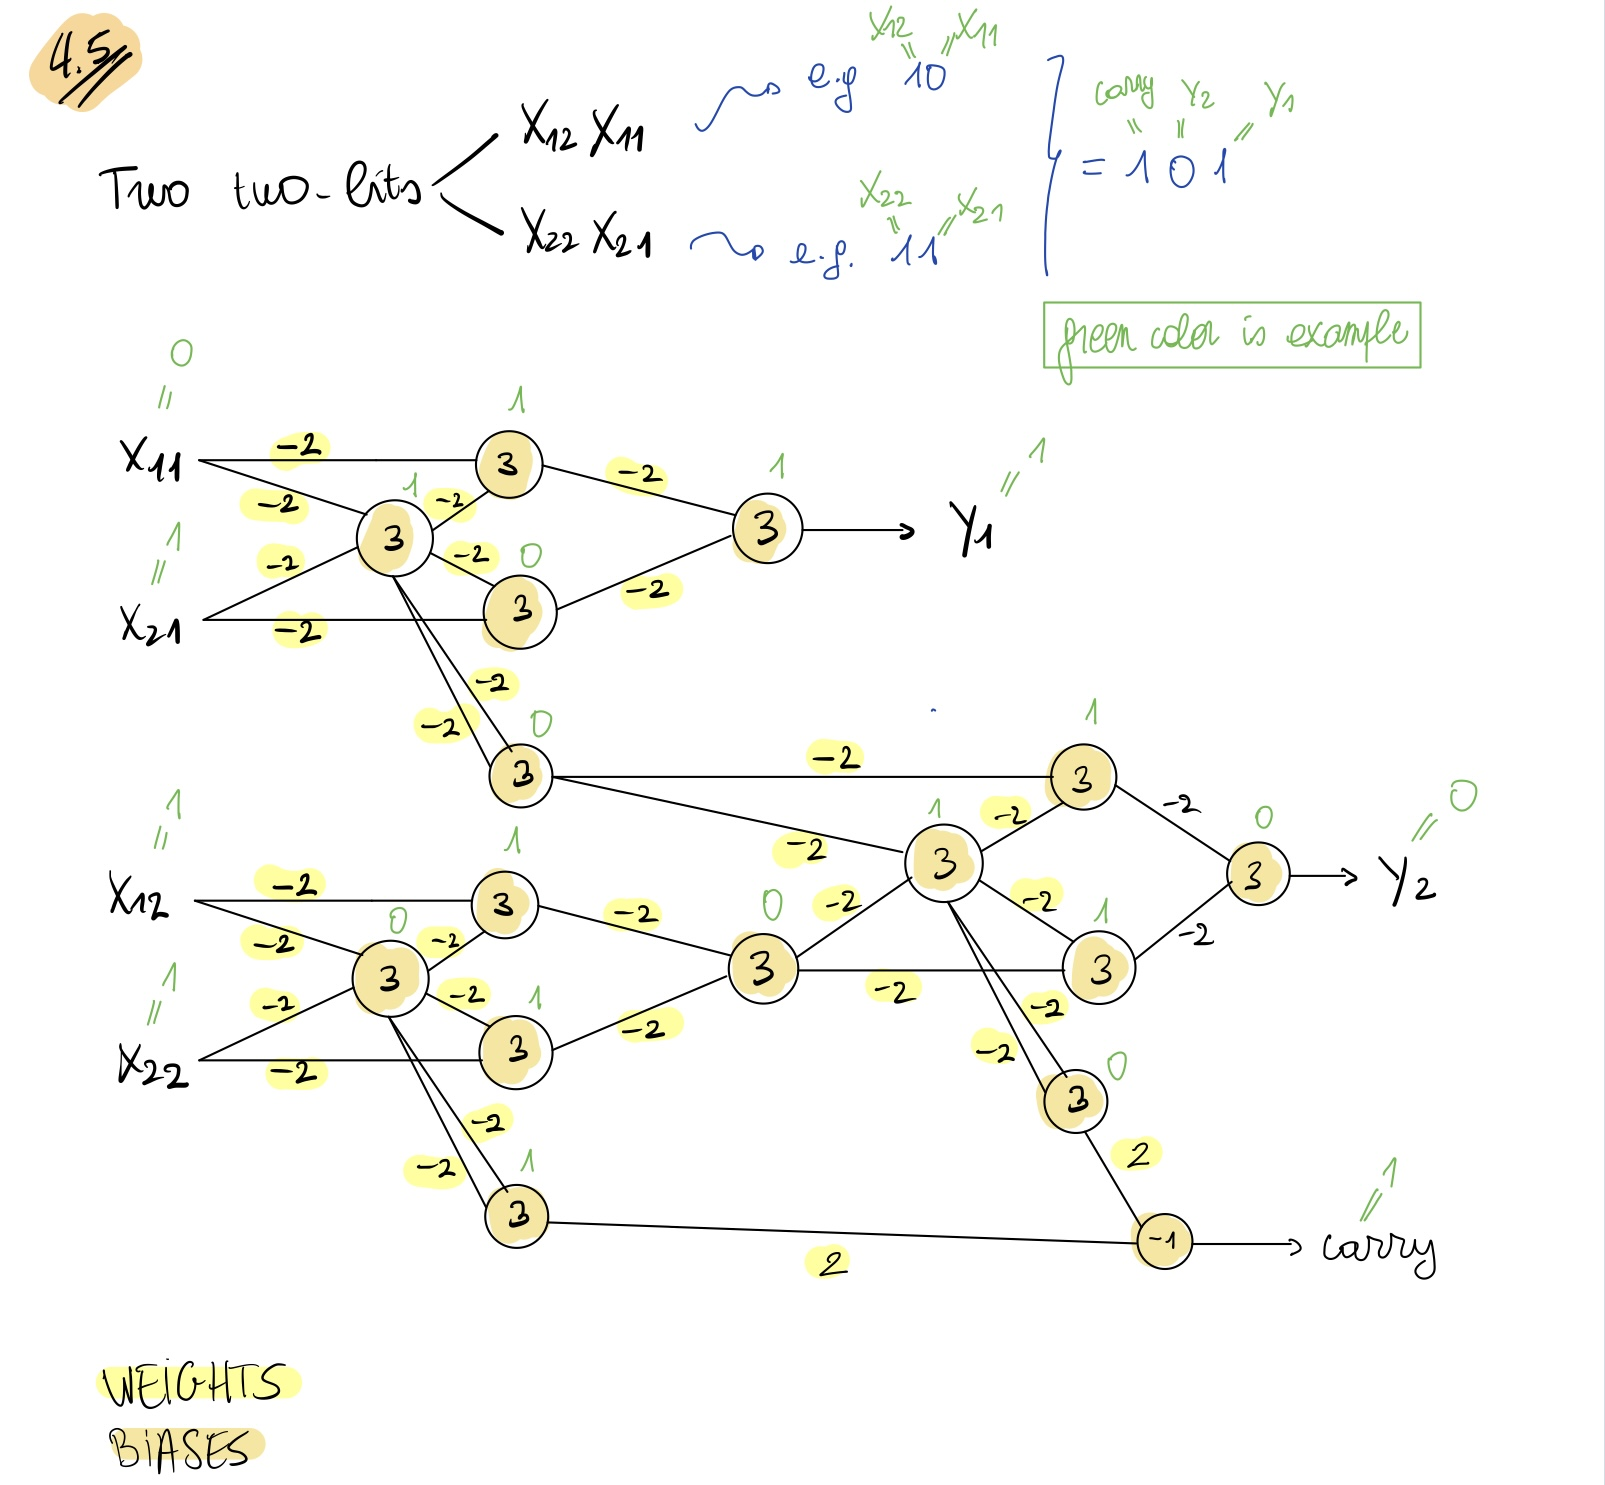

In [57]:
from IPython.display import Image
Image("IMG_0274.jpg")

The code below does a bitwise addition for every possible length of bit (so not restricted to two bits) so it is not part of the question.

In [25]:
def NAND_percep(x1, x2):
    v = -2*x1 - 2*x2 + 3
    if v>= 0:
        return 1
    else:
        return 0

In [26]:
def bitwise_addition(a,b):
    max_len = max(len(a), len(b))

    if (len(a) < len(b)):
        diffzeros = [0] * (len(b)-len(a))
        a = diffzeros + a
    if (len(b) < len(a)):
        diffzeros = [0] * (len(a)-len(b))
        b = diffzeros + b

    result = []
    carry = 0

    for i in range(max_len - 1, -1, -1):
        a11 = NAND_percep(a[i],b[i])
        a21 = NAND_percep(a[i],a11)
        a22 = NAND_percep(b[i],a11)
        result = list(map(int, str(NAND_percep(a21,a22) + carry))) + result
        carry = NAND_percep(a11,a11)

    if result[0] == 2:
        result = [1] + result
        result[1] = 0
    if result[0] == 0:
        result = [1] + result

    return result

In [27]:
a = [1,1,0,1]
b = [1,0,0,1]

bitwise_addition(a,b)

[1, 0, 1, 1, 0]

# Problem 5

### Problem 5.1

In [12]:
""" Neural Network.
A 2-Hidden Layers Fully Connected Neural Network (a.k.a Multilayer Perceptron)
implementation with PyTorch. This example is using the MNIST database
of handwritten digits (http://yann.lecun.com/exdb/mnist/).
"""
import torch
import torch.nn as nn  # neural network modules
import torch.nn.functional as F  # activation functions
import torch.optim as optim  # optimizer
from torch.autograd import Variable # add gradients to tensors
from torch.nn import Parameter # model parameter functionality

import torchvision
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  

torch.manual_seed(42)

In [2]:
# Helper functions
def get_accuracy(output, targets):
    """calculates accuracy from model output and targets
    """
    output = output.detach()
    predicted = output.argmax(-1)
    correct = (predicted == targets).sum().item()

    accuracy = correct / output.size(0) * 100

    return accuracy


def to_one_hot(y, c_dims=10):
    """converts a N-dimensional input to a NxC dimnensional one-hot encoding
    """
    y_tensor = y.data if isinstance(y, Variable) else y
    y_tensor = y_tensor.type(torch.LongTensor).view(-1, 1)
    c_dims = c_dims if c_dims is not None else int(torch.max(y_tensor)) + 1
    y_one_hot = torch.zeros(y_tensor.size()[0], c_dims).scatter_(1, y_tensor, 1)
    y_one_hot = y_one_hot.view(*y.shape, -1)
    return Variable(y_one_hot) if isinstance(y, Variable) else y_one_hot

def lp_reg(params,p=1):
    sum = 0
    for w in params:
        if len(w.shape) > 1: # if this isn't a bias
            sum += torch.sum(w**p)
    return sum ** (1/p)

In [3]:
# import data
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

In [4]:
# training data

train_data = mnist_trainset.data.to(dtype=torch.float32)
train_data = train_data.reshape(-1, 784)
train_labels = mnist_trainset.targets.to(dtype=torch.long)

print("train data shape: {}".format(train_data.size()))
print("train label shape: {}".format(train_labels.size()))

train data shape: torch.Size([60000, 784])
train label shape: torch.Size([60000])


In [5]:
# testing data
test_data = mnist_testset.data.to(dtype=torch.float32)[:2000]
test_data = test_data.reshape(-1, 784)
test_labels = mnist_testset.targets.to(dtype=torch.long)[:2000]

print("test data shape: {}".format(test_data.size()))
print("test label shape: {}".format(test_labels.size()))

test data shape: torch.Size([2000, 784])
test label shape: torch.Size([2000])


In [6]:
# load into torch datasets
train_dataset = torch.utils.data.TensorDataset(train_data, train_labels)
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)

In [7]:
# Parameters
learning_rate = 0.001 
num_epochs = 200 
batch_size = 128

# Network Parameters
n_hidden_1 = 2500 # 1st layer number of neurons
n_hidden_2 = 2000 # 2nd layer number of neurons
n_hidden_3 = 1500 # 3rd layer number of neurons
n_hidden_4 = 1000 # 4th layer number of neurons
n_hidden_5 = 500 # 5th layer number of neurons
num_input = 784  # MNIST data input (img shape: 28*28)
num_classes = 10  # MNIST total classes (0-9 digits)

In [8]:
# defining the model
class Fully_Connected_Neural_Net(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Fully_Connected_Neural_Net, self).__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        self.layer1 = nn.Linear(input_dim, n_hidden_1)
        self.layer2 = nn.Linear(n_hidden_1, n_hidden_2)
        self.layer3 = nn.Linear(n_hidden_2, n_hidden_3)
        self.layer4 = nn.Linear(n_hidden_3, n_hidden_4)
        self.layer5 = nn.Linear(n_hidden_4, n_hidden_5)
        self.layer6 = nn.Linear(n_hidden_5, output_dim)
        
        self.nonlin1 = nn.Sigmoid()
        self.nonlin2 = nn.ReLU()
        self.nonlin3 = nn.Softplus()
        self.nonlin4 = nn.ELU()
        self.nonlin5 = nn.Tanh()
        
        self.dropout = nn.Dropout(0.5)
        

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.dropout(x)
        x = self.nonlin2(self.layer1(x))
        x = self.nonlin2(self.layer2(x))
        x = self.nonlin2(self.layer3(x))
        x = self.nonlin2(self.layer4(x))
        x = self.nonlin2(self.layer5(x))
        x = self.layer6(x)
        return F.log_softmax(x, 0)

In [9]:
# creata dataloader
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,shuffle=True)

# These might be handy
CELoss = torch.nn.CrossEntropyLoss()
softmax = torch.nn.Softmax()
sigmoid = torch.nn.Sigmoid()

In [10]:
# main training function

def train():

    model = Fully_Connected_Neural_Net(num_input, num_classes)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # initialize loss list
    metrics = [[0, 0]]

    # iterate over epochs
    for ep in range(num_epochs):
        model.train()

        # iterate over batches
        for batch_indx, batch in enumerate(trainloader):

            # unpack batch
            data, labels = batch
            
            optimizer.zero_grad() 
            preds = model(data) 
            loss = CELoss(preds,labels) 
            loss.backward() 
            optimizer.step() 
        # And here you might put things that run every epoch
        # ...

        # every epoch
        model.eval()# model will not calculate gradients for this pass, and will disable dropout
        
        train_ep_pred = model(train_data)
        test_ep_pred = model(test_data)

        train_accuracy = get_accuracy(train_ep_pred, train_labels)
        test_accuracy = get_accuracy(test_ep_pred, test_labels)
        
        

        # print loss every epoch
        if ep % 1 == 0:
            print("train acc: {}\t test acc: {}\t at epoch: {}".format(train_accuracy,test_accuracy,ep))
        metrics.append([train_accuracy, test_accuracy])

    return np.array(metrics), model

def plot_accuracies_v_epoch(metric_array):
    epochs = np.arange(len(metric_array))
    plt.plot(epochs,metric_array[:,0], label="Train")
    plt.plot(epochs,metric_array[:,1], label="Test")
    plt.legend()
    plt.xlabel("Number of epochs")
    plt.ylabel("Accuracy")
    plt.show()


In [11]:
test_nums = len(test_dataset)
predicted = trained_model(test_data).detach()
output_num = predicted.argmax(-1)
real_num = mnist_testset.targets[:2000]


stacked = torch.stack(
    (
        real_num
        ,output_num
    )
    ,dim=1
)

cmt = torch.zeros(10,10, dtype=torch.int64)

for p in stacked:
    tl, pl = p.tolist()
    cmt[tl, pl] = cmt[tl, pl] + 1
    
plt.figure(figsize=(10,10))
plot_confusion_matrix(cmt, mnist_testset.classes)

NameError: name 'trained_model' is not defined